# ResNet-18 (Augmented + LR Scheduler)

## Changes from Unfreeze Baseline

### What changed
| | Unfreeze | Augmented |
|---|---|---|
| Augmentation | HFlip + ±10° rotation | HFlip + VFlip + ±30° rotation + ColorJitter + RandomAffine |
| Optimizer | Adam | AdamW |
| Weight decay | None | 1e-4 (decoupled) |
| LR scheduler | None | CosineAnnealingLR |
| Dropout | None | 0.4 before FC |
| Inference | Single pass | TTA (8 augmented passes averaged) |

### Rationale
The unfreeze model overfits heavily — train F2 reaches 0.97 while val F2 peaks at 0.78. Three changes target this:

1. **Stronger augmentation**: More transforms (vertical flip, wider rotation, color jitter, affine shifts) force the model to learn general melanoma features rather than memorizing specific training images.

2. **AdamW + weight decay**: AdamW decouples weight decay from the gradient update, fixing a known issue with standard Adam where weight decay interacts incorrectly with adaptive learning rates. This is the correct way to apply L2 regularization with Adam-style optimizers.

3. **Dropout (0.4)**: Applied before the FC layer, dropout randomly disables 40% of neurons during training, preventing any single pathway from dominating and forcing more robust feature learning.

4. **Test-Time Augmentation (TTA)**: At inference, each image is passed through 8 different augmentations (flips, rotations). The sigmoid probabilities are averaged before thresholding, giving a more stable and accurate prediction without any retraining.

In [1]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves

In [2]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=224),
)

train_df = pd.read_csv(ROOT / 'data_new/splits/train.csv')

num_melanoma = (train_df['label'] == 1).sum()   # melanoma in CSV (label=1)
num_nevus = (train_df['label'] == 0).sum()      # nevus in CSV (label=0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=False, dropout=0.4).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 20
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

Positive weight: tensor([8.1117], device='cuda:0')


In [5]:
best_val_f2 = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), ROOT / 'models/resnet_augmented_v2_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.9214, Bal Acc: 0.7413, Recall: 0.7948, F2: 0.5423 | Val Loss: 0.8878, Bal Acc: 0.7597, Recall: 0.7924, F2: 0.5775
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.8199, Bal Acc: 0.7841, Recall: 0.8324, F2: 0.5967 | Val Loss: 0.7925, Bal Acc: 0.7841, Recall: 0.7712, F2: 0.6111
Saved best model at epoch 2


Epoch [3/20] | Train Loss: 0.7609, Bal Acc: 0.7955, Recall: 0.8347, F2: 0.6128 | Val Loss: 0.7572, Bal Acc: 0.7945, Recall: 0.8686, F2: 0.6216
Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.7287, Bal Acc: 0.8148, Recall: 0.8632, F2: 0.6386 | Val Loss: 0.8123, Bal Acc: 0.7987, Recall: 0.8390, F2: 0.6290
Saved best model at epoch 4


Epoch [5/20] | Train Loss: 0.6921, Bal Acc: 0.8189, Recall: 0.8563, F2: 0.6460 | Val Loss: 0.8622, Bal Acc: 0.7945, Recall: 0.7288, F2: 0.6296
Saved best model at epoch 5


...

Epoch [16/20] | Train Loss: 0.3737, Bal Acc: 0.9162, Recall: 0.9441, F2: 0.8069 | Val Loss: 1.0231, Bal Acc: 0.7766, Recall: 0.6695, F2: 0.6031


Epoch [17/20] | Train Loss: 0.3415, Bal Acc: 0.9182, Recall: 0.9384, F2: 0.8137 | Val Loss: 1.1742, Bal Acc: 0.7671, Recall: 0.6186, F2: 0.5882


Epoch [18/20] | Train Loss: 0.3412, Bal Acc: 0.9201, Recall: 0.9396, F2: 0.8176 | Val Loss: 1.0232, Bal Acc: 0.7931, Recall: 0.6992, F2: 0.6293


Epoch [19/20] | Train Loss: 0.3099, Bal Acc: 0.9308, Recall: 0.9544, F2: 0.8362 | Val Loss: 1.0913, Bal Acc: 0.7876, Recall: 0.6737, F2: 0.6216


Epoch [20/20] | Train Loss: 0.3173, Bal Acc: 0.9326, Recall: 0.9544, F2: 0.8405 | Val Loss: 1.1125, Bal Acc: 0.7762, Recall: 0.6525, F2: 0.6030


## Training Curves

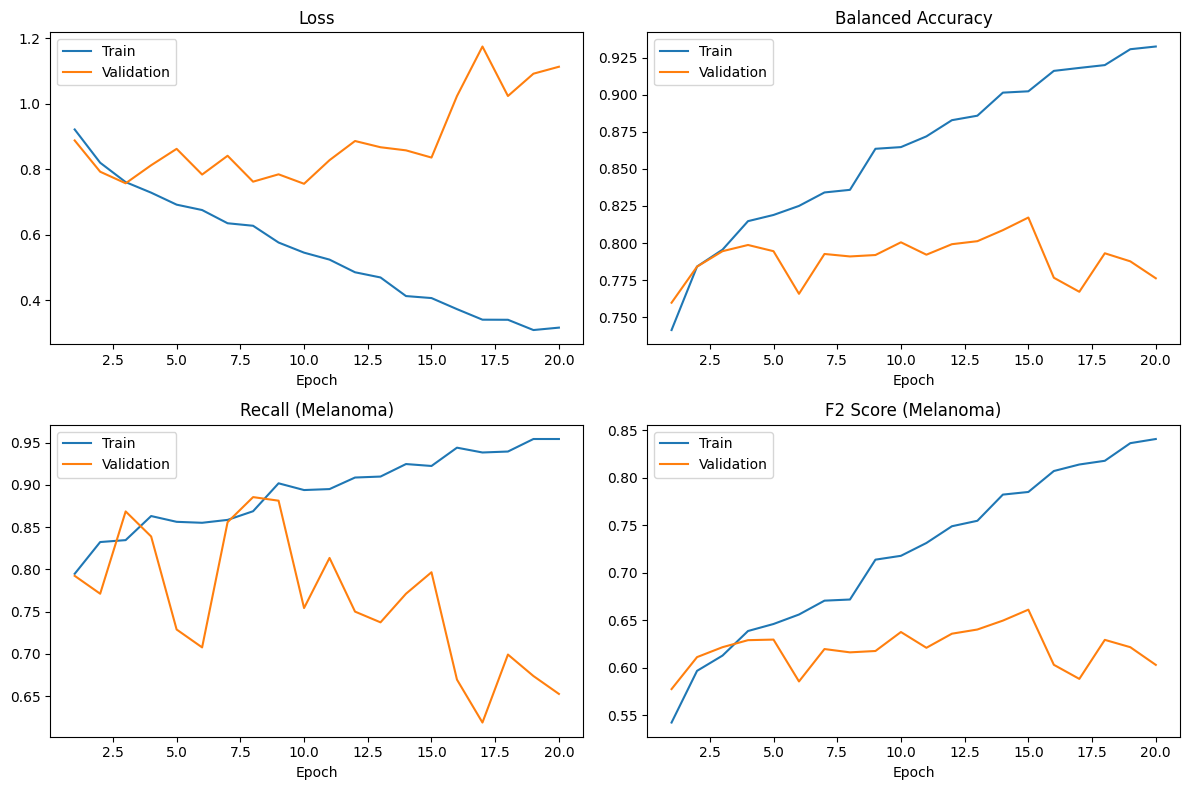

In [6]:
plot_training_curves(train_history, val_history)

## Threshold Tuning

In [7]:
import numpy as np
from sklearn.metrics import fbeta_score
from torchvision import transforms

model.load_state_dict(torch.load(str(ROOT / 'models/resnet_augmented_v2_best.pth'), map_location=device))
model.eval()

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

tta_transforms = [
    transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(90, 90)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(180, 180)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(270, 270)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.ColorJitter(brightness=0.1, contrast=0.1), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

def tta_predict(model, dataset, device, tta_transforms):
    all_probs = []
    all_labels = []

    for idx in range(len(dataset)):
        image_id = dataset.data.iloc[idx]['image_id']
        label = int(dataset.data.iloc[idx]['label'])
        from PIL import Image
        img = Image.open(dataset.image_dir / (image_id + '.jpg')).convert('RGB')

        preds = []
        with torch.no_grad():
            for t in tta_transforms:
                tensor = t(img).unsqueeze(0).to(device)
                prob = torch.sigmoid(model(tensor)).item()
                preds.append(prob)

        all_probs.append(np.mean(preds))
        all_labels.append(label)

    return np.array(all_probs), np.array(all_labels)

val_probs, val_labels = tta_predict(model, val_loader.dataset, device, tta_transforms)

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (val_probs >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Best threshold: 0.54 | Val F2: 0.6835


Threshold:          0.54
AUC-ROC:            0.9133
Balanced Accuracy:  0.8236
F2 Score:           0.6704

              precision    recall  f1-score   support

Non-Melanoma     0.9684    0.8694    0.9162      1340
    Melanoma     0.4318    0.7778    0.5553       171

    accuracy                         0.8590      1511
   macro avg     0.7001    0.8236    0.7358      1511
weighted avg     0.9077    0.8590    0.8754      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


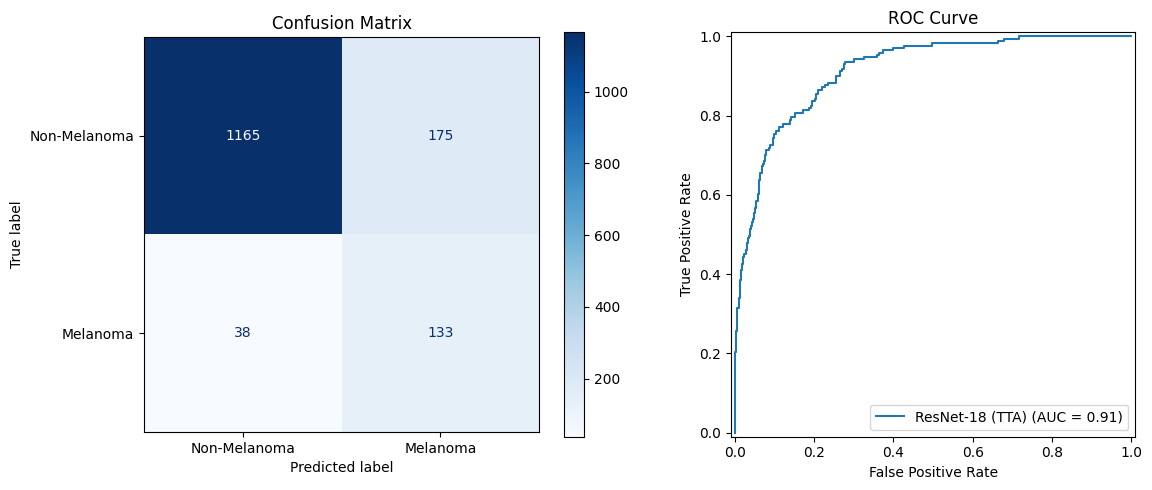

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, fbeta_score, roc_auc_score, roc_curve, RocCurveDisplay,
)

test_probs, test_labels = tta_predict(model, test_loader.dataset, device, tta_transforms)
all_preds = (test_probs >= best_threshold).astype(int)

auc     = roc_auc_score(test_labels, test_probs)
bal_acc = balanced_accuracy_score(test_labels, all_preds)
f2      = fbeta_score(test_labels, all_preds, beta=2, pos_label=1, zero_division=0)

print(f"Threshold:          {best_threshold:.2f}")
print(f"AUC-ROC:            {auc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"F2 Score:           {f2:.4f}")
print()
print(classification_report(test_labels, all_preds, target_names=["Non-Melanoma", "Melanoma"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(test_labels, all_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"]).plot(cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")
fpr, tpr, _ = roc_curve(test_labels, test_probs)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name="ResNet-18 (TTA)").plot(ax=axes[1])
axes[1].set_title("ROC Curve")
fig.tight_layout()
plt.show()